In [1]:
print("hola")

hola


Base Emision

In [2]:
pip install gdown pandas

In [22]:
import gdown
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:


# URL o solo el ID del archivo
url_or_id = "https://drive.google.com/file/d/1bPACUN9vW7vptM2buw2OgUS1ph8w3Pgw/view?usp=sharing"
dest = Path("data/archivo.csv")
dest.parent.mkdir(parents=True, exist_ok=True)

# gdown maneja la confirmación de archivos grandes
gdown.download(url=url_or_id, output=str(dest), quiet=False, fuzzy=True)

# Lectura por chunks para no agotar RAM (ajustá el chunksize a tu PC)
chunks = pd.read_csv(dest, sep=";", encoding="utf-8", chunksize=200_000)
# Ejemplo: conteo de filas sin cargar todo
total_rows = 0
for chunk in chunks:
    total_rows += len(chunk)
print("Filas totales:", total_rows)


import pandas as pd
from pathlib import Path

dest = Path("data/archivo.csv")

Base_Emision = pd.read_csv(dest, sep=";", encoding="utf-8")
print(Base_Emision.head())


Downloading...
From (original): https://drive.google.com/uc?id=1bPACUN9vW7vptM2buw2OgUS1ph8w3Pgw
From (redirected): https://drive.google.com/uc?id=1bPACUN9vW7vptM2buw2OgUS1ph8w3Pgw&confirm=t&uuid=64e11df4-de67-4d5c-90a8-2f830b771ea7
To: c:\Users\d78157\Desktop\Personales\Facultad - Clases -Docencia\Tesis\01 Codigos\data\archivo.csv
100%|██████████| 1.66G/1.66G [02:25<00:00, 11.5MB/s]


Filas totales: 5188042
     Idcol     poliza  CD_item  ENDOSO  TIPO ENDOSO   FECHA_EMI     INI_VIG  \
0  5186991  4-1526667        1       1        99999  2018-04-25  2018-04-25   
1  5186992   4-366387        1       1        99999  2012-04-20  2012-04-20   
2  5186993  4-1647694        1       1        99999  2019-01-23  2019-01-23   
3  5186994   4-208091        1       1        99999  2011-11-26  2011-11-26   
4  5186995  4-1647694        1       2        99999  2019-03-22  2019-03-22   

      FIN_VIG   SUMASEG  SUMASEG_ACC  ...  VAR_15  VAR_16  VAR_17  VAR_18  \
0  2018-04-26  127600.0          0.0  ...       1       3       1       1   
1  2012-04-21       0.0          0.0  ...       2      18       1       9   
2  2019-01-24  770000.0          0.0  ...       1      17       1       1   
3  2011-11-27  138000.0          0.0  ...     999     999     999     999   
4  2019-03-23  770000.0          0.0  ...       1      17       1       1   

   VAR_19  VAR_20  Exp_Rc_365  Exp_Casc

In [4]:
# ANÁLISIS DE CALIDAD DE DATOS
# Ver si mi DataFrame no tiene ningún valor faltante (NaN)

missing_pct = (Base_Emision.isna().mean() * 100).round(2)
display(missing_pct[missing_pct > 0].sort_values(ascending=False))

Series([], dtype: float64)

In [5]:
# Variables con muchos ceros.

for c in Base_Emision.select_dtypes(include="number").columns:
    ratio = (Base_Emision[c] == 0).mean()
    if ratio > 0.95:
        print(f"{c}: {ratio:.2%} ceros")

PR_RCL: 100.00% ceros
PR_RCD: 100.00% ceros
PR_RT: 100.00% ceros
PR_RP: 100.00% ceros
PR_DT: 100.00% ceros
PR_DP: 100.00% ceros
PR_IT: 100.00% ceros
PR_IP: 100.00% ceros
PR_CR: 100.00% ceros


In [6]:
# Filas Duplicados por póliza

Base_Emision[["poliza","CD_item","ENDOSO"]].duplicated().sum()

6

In [7]:
# Filas Duplicados por póliza


key_cols = ["poliza", "CD_item", "ENDOSO"]

dups_all = Base_Emision[Base_Emision.duplicated(subset=key_cols, keep=False)] \
            .sort_values(key_cols)

display(dups_all)

,Idcol,poliza,CD_item,ENDOSO,TIPO ENDOSO,FECHA_EMI,INI_VIG,FIN_VIG,SUMASEG,SUMASEG_ACC,...,VAR_15,VAR_16,VAR_17,VAR_18,VAR_19,VAR_20,Exp_Rc_365,Exp_Casco_365,Exp_365,Cobertura
102,5187093,4-104633,40,1,99999,2011-03-09,2011-03-09,2011-03-10,300000.0,0.0,...,2,16,1,18,1,0,0.0100,0.0100,0.0100,RCyCasco
800215,799960,4-104633,40,1,99999,2011-03-01,2011-03-23,2012-03-23,300000.0,0.0,...,2,16,1,18,1,0,1.0027,1.0027,1.0027,RCyCasco
103,5187094,4-1566277,1,4,99999,2018-03-23,2018-03-23,2018-03-24,171600.0,0.0,...,1,1,1,1,3,0,0.0100,0.0100,0.0100,RCyCasco
2099893,5187456,4-1566277,1,4,99999,2018-03-23,2018-03-23,2018-03-24,185900.0,0.0,...,1,1,1,1,3,0,0.0100,0.0100,0.0100,RCyCasco
104,5187095,4-25036,1,2,99999,2015-08-06,2015-08-06,2015-08-07,66500.0,0.0,...,2,15,1,19,2,0,0.0100,0.0100,0.0100,RCyCasco
2099949,5187512,4-25036,1,2,99999,2015-08-06,2015-08-06,2015-08-07,66500.0,0.0,...,2,15,1,19,2,0,0.0100,0.0100,0.0100,RCyCasco
105,5187096,4-476275,3,2,99999,2012-07-28,2012-07-28,2012-07-29,110000.0,0.0,...,2,1,3,1,4,0,0.0100,0.0100,0.0100,RCyCasco
2100119,5187682,4-476275,3,2,99999,2012-07-28,2012-07-28,2012-07-29,110000.0,0.0,...,2,1,3,1,4,0,0.0100,0.0100,0.0100,RCyCasco
106,5187097,4-61589,1,2,99999,2016-05-13,2016-05-13,2016-05-14,10200.0,0.0,...,1,1,1,13,1,0,0.0100,0.0100,0.0100,RCyCasco
2100226,5187789,4-61589,1,2,99999,2016-05-13,2016-05-13,2016-05-14,10200.0,0.0,...,1,1,1,13,1,0,0.0100,0.0100,0.0100,RCyCasco


In [10]:
# 4. DESCRIPTIVO DE COLUMNAS NUMÉRICAS (primas + sumas aseguradas)


num_cols = Base_Emision.select_dtypes(include=np.number).columns
Base_Emision[num_cols].describe(percentiles=[0.01,0.05,0.5,0.95,0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
Idcol,5188042.0,2.594022e+06,1.497659e+06,1.00,51881.41,259403.0500,2.594022e+06,4.928640e+06,5.136162e+06,5.188042e+06
CD_item,5188042.0,1.658231e+02,6.891017e+02,1.00,1.00,1.0000,1.000000e+00,1.130000e+03,3.626000e+03,8.954000e+03
ENDOSO,5188042.0,1.657233e+00,8.878875e-01,1.00,1.00,1.0000,1.000000e+00,3.000000e+00,4.000000e+00,1.500000e+01
TIPO ENDOSO,5188042.0,9.999900e+04,0.000000e+00,99999.00,99999.00,99999.0000,9.999900e+04,9.999900e+04,9.999900e+04,9.999900e+04
SUMASEG,5188042.0,1.192924e+05,2.490434e+05,0.00,0.00,0.0000,2.800000e+04,4.950000e+05,1.100000e+06,3.450000e+07
SUMASEG_ACC,5188042.0,2.512745e+03,2.718101e+04,0.00,0.00,0.0000,0.000000e+00,9.000000e+03,5.000000e+04,6.627225e+06
PR_CASCO,5188042.0,1.311840e+03,4.429884e+03,-25321.12,0.00,0.0000,1.841200e+02,5.473439e+03,1.669926e+04,4.618324e+05
PR_RC,5188042.0,9.308853e+02,1.313846e+03,-25111.84,3.12,74.5300,5.372100e+02,3.094370e+03,6.430926e+03,4.543589e+04
PR_RCL,5188042.0,0.000000e+00,0.000000e+00,0.00,0.00,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
PR_RCD,5188042.0,0.000000e+00,0.000000e+00,0.00,0.00,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [11]:
# 5. CATEGÓRICAS: principales distribuciones (Cobertura)


Base_Emision["Cobertura"].value_counts(dropna=False)

RCyCasco    2833933
Rc          2351603
Casco          2506
Name: Cobertura, dtype: int64

In [12]:
#  6. ANÁLISIS POR COBERTURA (TOTAL PRIMA + CANTIDAD)



tabla = (
    Base_Emision.groupby("Cobertura")
      .agg(
          prima_total = ("Exp_365", "sum"),
          cantidad_polizas = ("poliza", "count")
      )
      .reset_index()
)

# Fila total
tabla.loc["TOTAL"] = ["TOTAL", tabla["prima_total"].sum(), tabla["cantidad_polizas"].sum()]
display(tabla)

,Cobertura,prima_total,cantidad_polizas
0,Casco,1.148118e+03,2506
1,RCyCasco,1.066601e+06,2833933
2,Rc,9.264470e+05,2351603
TOTAL,TOTAL,1.994196e+06,5188042


In [13]:
# 7. FECHAS: análisis de emisión y vigencia


cols_fecha = ["FECHA_EMI", "INI_VIG", "FIN_VIG"]

for c in cols_fecha:
    Base_Emision[c] = pd.to_datetime(Base_Emision[c], errors="coerce", dayfirst=False)



In [14]:
Base_Emision[cols_fecha].isna().mean().sort_values(ascending=False) * 100

FECHA_EMI    0.0
INI_VIG      0.0
FIN_VIG      0.0
dtype: float64

Vemos que no se perdió ninguna fecha en la conversión (0% de faltantes).

In [15]:
Base_Emision["FECHA_EMI"].dt.year.value_counts().sort_index()
Base_Emision["INI_VIG"].dt.month.value_counts().sort_index()

1     445710
2     378615
3     434642
4     433297
5     522711
6     417991
7     392478
8     460671
9     413408
10    393567
11    446971
12    447981
Name: INI_VIG, dtype: int64

In [16]:
tabla_calendario = pd.crosstab(
    Base_Emision["FECHA_EMI"].dt.year,
    Base_Emision["FECHA_EMI"].dt.month
)

tabla_calendario

FECHA_EMI,1,2,3,4,5,6,7,8,9,10,11,12
FECHA_EMI,,,,,,,,,,,,
2008,0,0,0,0,0,0,0,0,0,0,0,4
2009,27,505,1483,2242,2467,4911,1886,5530,5497,3067,4784,4867
2010,7027,5833,7197,7626,13428,10277,8012,12913,12399,10410,11635,13907
2011,17176,10588,16983,14590,22345,21294,18549,31219,29797,28463,30627,33409
2012,35407,29627,36263,31148,41176,35441,45075,58789,42298,37474,42819,55655
2013,41695,34085,42234,45128,51912,35647,42409,51419,42909,41934,49169,51282
2014,50312,46134,50968,57475,57686,47863,53273,59453,58783,55414,62407,57645
2015,58914,55157,59134,64144,76490,52198,57121,62858,62655,60866,60894,54602
2016,56809,50552,55392,57032,69529,61241,60036,65206,57414,58810,69333,68001


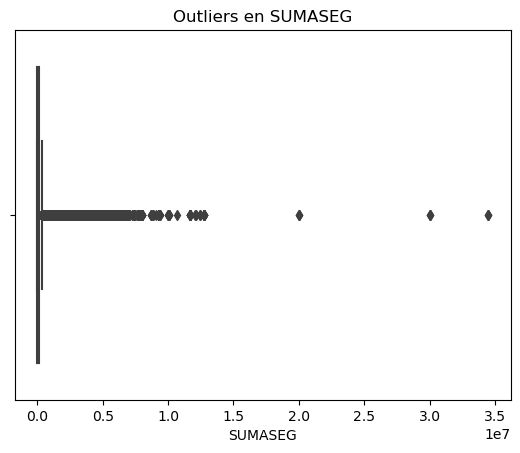

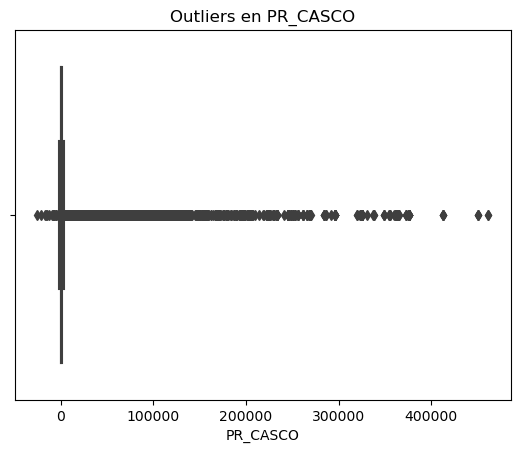

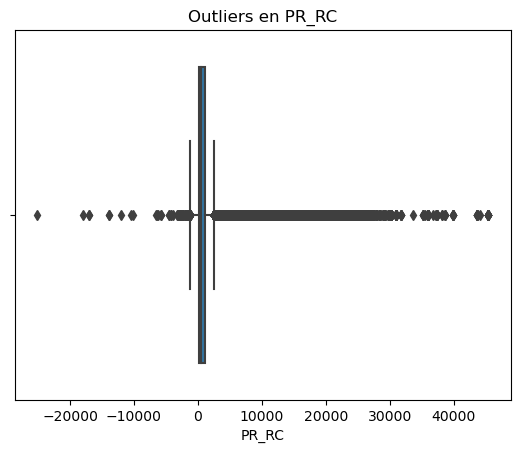

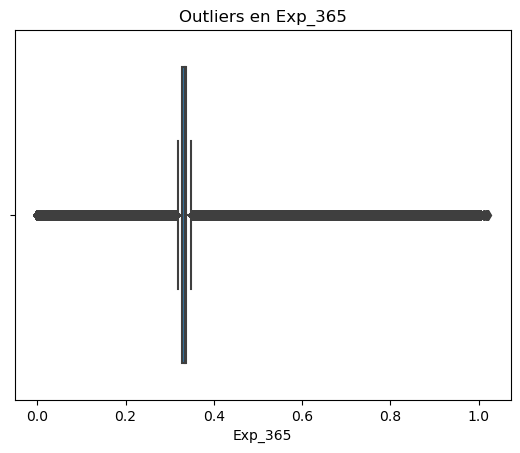

In [23]:
# 8. OUTLIERS (muy importante en primas y sumas aseguradas)


for c in ["SUMASEG","PR_CASCO","PR_RC","Exp_365"]:
    sns.boxplot(x=Base_Emision[c])
    plt.title(f"Outliers en {c}")
    plt.show()

In [24]:
cols = ["SUMASEG", "PR_CASCO", "PR_RC", "Exp_365"]
data = Base_Emision[cols].copy()


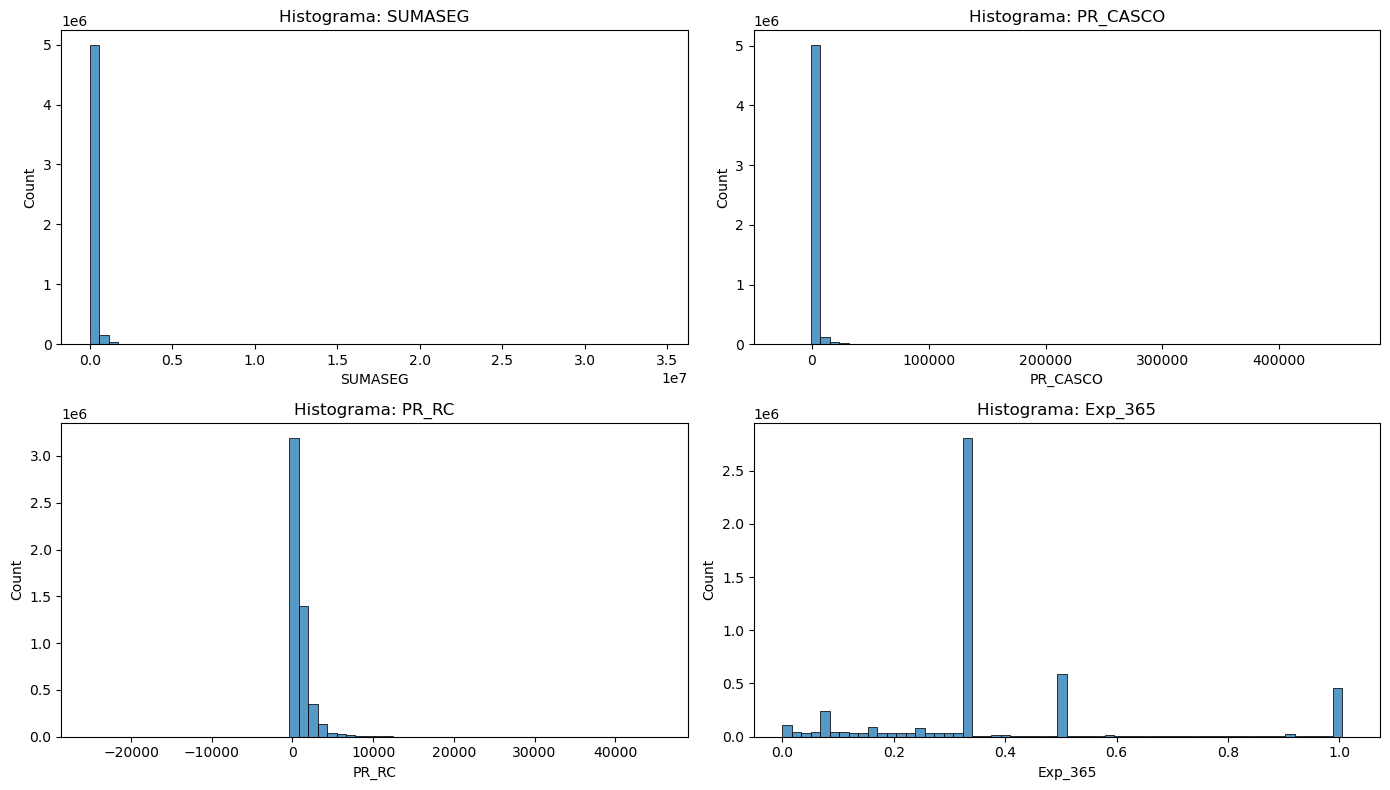

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, c in zip(axes, cols):
    x = Base_Emision[c].dropna()
    sns.histplot(x, bins=60, ax=ax)
    ax.set_title(f"Histograma: {c}")
plt.tight_layout()
plt.show()

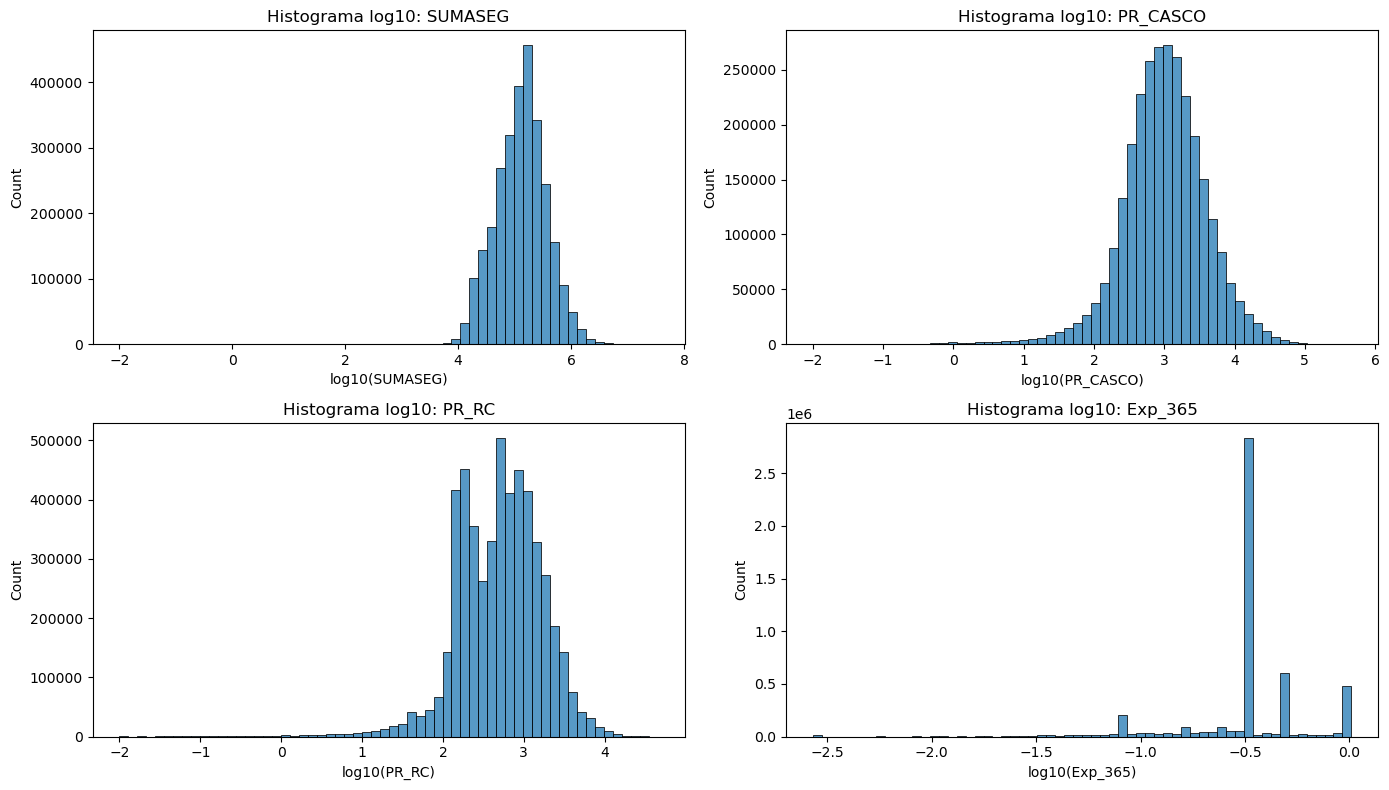

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, c in zip(axes, cols):
    x = Base_Emision[c].dropna()
    x = x[x > 0]  # log requiere >0
    sns.histplot(np.log10(x), bins=60, ax=ax)
    ax.set_title(f"Histograma log10: {c}")
    ax.set_xlabel(f"log10({c})")
plt.tight_layout()
plt.show()

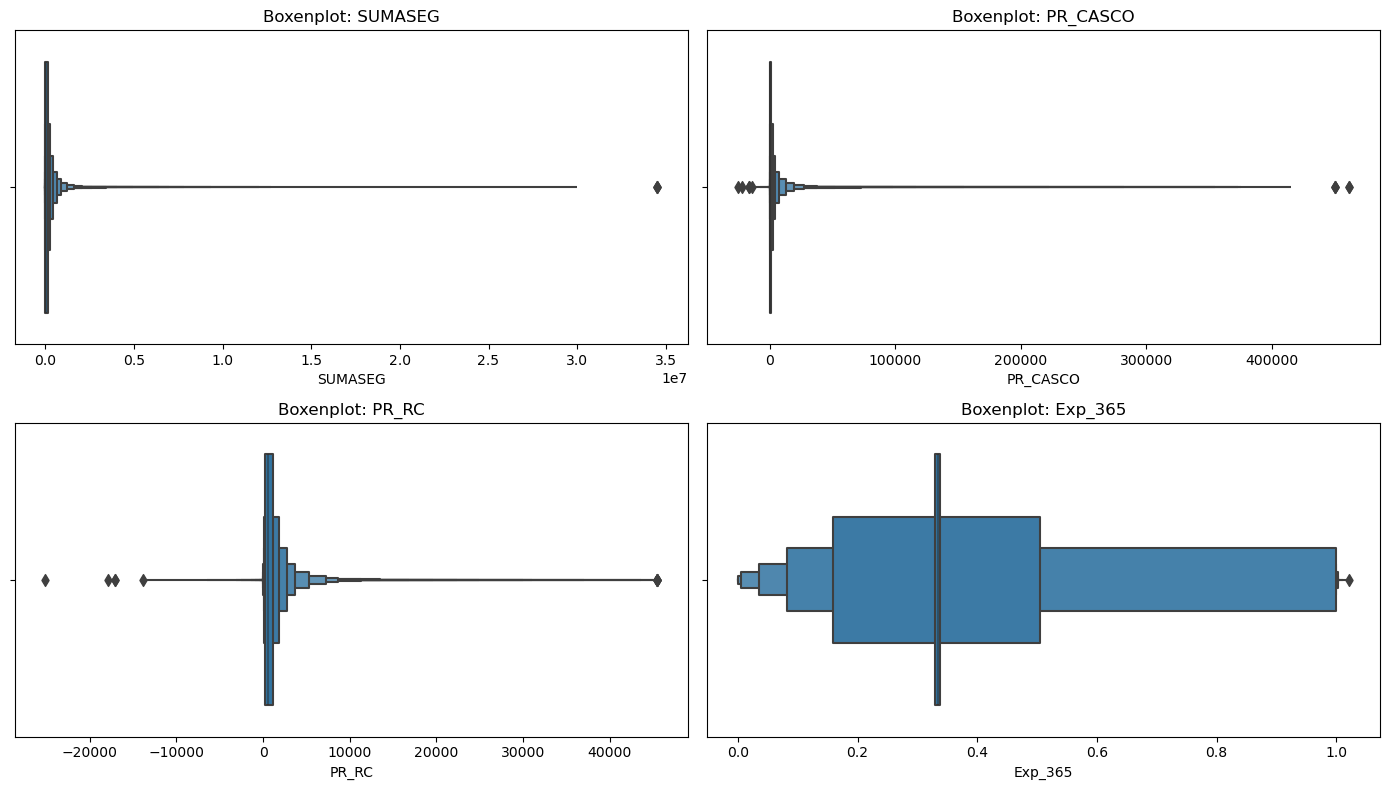

In [27]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, c in zip(axes, cols):
    sns.boxenplot(x=Base_Emision[c], ax=ax)
    ax.set_title(f"Boxenplot: {c}")
plt.tight_layout()
plt.show()


In [28]:

def outlier_iqr_mask(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return (s < lo) | (s > hi), lo, hi

for c in cols:
    mask, lo, hi = outlier_iqr_mask(Base_Emision[c].dropna())
    print(c, "IQR low/high:", lo, hi, "| outliers:", mask.mean())


SUMASEG IQR low/high: -226500.0 377500.0 | outliers: 0.07812118714536236
PR_CASCO IQR low/high: -1723.5412499999998 2872.5687499999995 | outliers: 0.10875991366299656
PR_RC IQR low/high: -1180.8800000000003 2509.6000000000004 | outliers: 0.07298225419146569
Exp_365 IQR low/high: 0.3164999999999998 0.34930000000000017 | outliers: 0.4547696414177063


In [ ]:
for c in cols:
    display(Base_Emision[[c]].sort_values(c, ascending=False).head(20))


,SUMASEG
2997410,34500000.0
2997399,34500000.0
2997388,34500000.0
2967244,30000000.0
2967233,30000000.0
2967222,30000000.0
2561546,20000000.0
2561535,20000000.0
2561524,20000000.0
2924689,12735360.0


,PR_CASCO
2569316,461832.37
2569317,461832.37
2230118,450190.58
2230126,450190.58
2230124,450190.58
2543294,413278.06
2543292,413278.06
2543296,413278.06
2543295,413278.06
2212682,375752.98


,PR_RC
2445426,45435.89
2445414,45435.73
2445421,45435.73
2445423,45435.73
2445420,45435.73
2445425,45435.46
2445427,45435.46
2445424,45435.46
2445416,45435.37
2445417,45435.37


,Exp_365
5077504,1.0219
3038357,1.0192
3038356,1.0192
3038355,1.0192
3038354,1.0192
3038353,1.0192
3038352,1.0192
3038351,1.0192
3038350,1.0192
3038347,1.0192
